# Notebook 02 — High-Level Feature MLP Baseline

**Course:** Machine Learning for Physics and Astrophysics  
**Project:** Deep Learning for Top Quark Identification with ATLAS Open Data  

---

## Motivation

This notebook implements the **first actual classifier** in the project: a Multilayer Perceptron (MLP) trained exclusively on the **15 hand-crafted high-level jet substructure features** provided in the ATLAS Top Tagging dataset.

Using only high-level features is a natural first step because:

- The features are compact (15 numbers per jet), making training fast and easy to iterate on.
- They encode well-motivated physics quantities (N-subjettiness, ECF ratios, splitting scales), so a well-trained MLP over them already achieves meaningful discrimination.
- This baseline establishes a **reference performance** against which later, more powerful architectures — constituent-based MLPs, CNNs operating on jet images, ParticleNet/graph networks, transformers — will be compared.

---

## 1. Method Overview

The pipeline implemented in this notebook is:

```
HDF5 file
   └─ load 15 high-level features → X  (N, 15)  float32
   └─ load labels               → y  (N,)     int / float
   └─ load training_weights     → w  (N,)     float32
         │
         ▼
train / validation split  (80 / 20, stratified)
         │
         ▼
StandardScaler  (fit on X_train only, then transform both splits)
         │ (prevenir data leakage, ayudar convergencia del optimizador)
         ▼
PyTorch Dataset  →  DataLoader  (batched, shuffled)
         │ (Preparamos para training con batching, shuffling, masking de pesos...)
         ▼
MLP: Linear→BN→ReLU→Dropout  (×3 hidden layers)  →  Linear(1)  (logit)
         │ (MLP feedforward [15→128→64→32→1]) con una architecture Linear→BN→ReLU→Dropout 
         |  repetido 3 veces y Output: LOGIT (no probabilidad)  
         ▼
Weighted BCE loss:  mean[ w_i · BCE(logit_i, y_i) ]
         │  Hacemos un reweighting para eliminar background sculpting y calculamos el loss
         ▼
PyTorch Lightning Trainer  (Adam, EarlyStopping, ModelCheckpoint)
         │ Adaptativo, learning rate scheduler y prevenimos overfitting
         ▼
Evaluation on validation set:
   accuracy, AUC, ROC curve, background rejection, score distribution
```

The classes and functions defined here are written in a style that can later be extracted into `src/` modules.

---

## 2. Imports and Reproducibility

In [1]:
import json
import warnings
from pathlib import Path

import h5py #(Lectura de archivos .h5, que es el formato de nuestros datasets)
import numpy as np #(Operaciones matriciales en CPU, carga de datos)
import pandas as pd
import matplotlib.pyplot as plt #visualizacion de datos, gráficos de entrenamiento, curvas ROC, etc.
import matplotlib.ticker as mticker

from sklearn.model_selection import train_test_split #sklearn para Preprocessing (StandardScaler, train_test_split)
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    roc_curve,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

import torch #(Operaciones matriciales en GPU, tensores, construcción de modelos, entrenamiento, evaluación)
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import pytorch_lightning as pl #(Entrenamiento, validación, callbacks, logging)
from pytorch_lightning.callbacks import EarlyStopping, ModelCheckpoint
from pytorch_lightning.loggers import CSVLogger

warnings.filterwarnings("ignore", category=UserWarning)

# ── Reproducibility ────────────────────────────────────────────────────────────
RANDOM_SEED = 42
pl.seed_everything(RANDOM_SEED, workers=True)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

# ── Hardware ───────────────────────────────────────────────────────────────────
DEVICE = "cuda" if torch.cuda.is_available() else "cpu" #hardware detection (GPU o CPU)
print(f"PyTorch version      : {torch.__version__}")
print(f"PyTorch Lightning    : {pl.__version__}")
print(f"CUDA available       : {torch.cuda.is_available()}")
print(f"Active device        : {DEVICE}")

Seed set to 42


PyTorch version      : 2.11.0
PyTorch Lightning    : 2.6.1
CUDA available       : False
Active device        : cpu


---

## 3. Path Configuration

In [2]:
# ── Resolve DATA_PATH regardless of whether the notebook is run from
#    notebooks/ or from the project root ──────────────────────────────────────
def _find_data_path() -> Path:
    candidates = [
        Path("../data/raw/train_nominal_000.h5"),   # run from notebooks/
        Path("data/raw/train_nominal_000.h5"),       # run from project root
    ]
    for p in candidates:
        if p.exists():
            return p.resolve()
    raise FileNotFoundError(
        "Could not find train_nominal_000.h5. "
        "Expected at data/raw/train_nominal_000.h5 relative to the project root."
    )


def _find_project_root() -> Path:
    """Walk up from this file until we find the expected directory layout."""
    here = Path(".").resolve()
    for candidate in [here, here.parent]:
        if (candidate / "data").exists() or (candidate / "figures").exists():
            return candidate
    return here.parent   # fallback: parent of notebooks/


PROJECT_ROOT  = _find_project_root()
DATA_PATH     = _find_data_path()
FIGURE_DIR    = PROJECT_ROOT / "figures"
RESULT_DIR    = PROJECT_ROOT / "results"
CHECKPOINT_DIR = RESULT_DIR / "checkpoints" / "mlp_highlevel"
LOG_DIR        = RESULT_DIR / "logs"

for d in [FIGURE_DIR, RESULT_DIR, CHECKPOINT_DIR, LOG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f"Project root   : {PROJECT_ROOT}")
print(f"Data path      : {DATA_PATH}")
print(f"Figure dir     : {FIGURE_DIR}")
print(f"Result dir     : {RESULT_DIR}")
print(f"Checkpoint dir : {CHECKPOINT_DIR}")

Project root   : /Users/arturomatemartin/Desktop/ML_TopTagging_Project
Data path      : /Users/arturomatemartin/Desktop/ML_TopTagging_Project/data/raw/train_nominal_000.h5
Figure dir     : /Users/arturomatemartin/Desktop/ML_TopTagging_Project/figures
Result dir     : /Users/arturomatemartin/Desktop/ML_TopTagging_Project/results
Checkpoint dir : /Users/arturomatemartin/Desktop/ML_TopTagging_Project/results/checkpoints/mlp_highlevel


### How we got access to the data

We first cloned the GitHub repository. This gave us the project structure and code, for example the `data/`, `docs/`, `external/`, `notebooks/`, and `src/` folders. However, cloning the repository did **not** download the full ATLAS `.h5` dataset, because these files are too large to be stored directly in GitHub.

After cloning the repository, we checked that the external ATLAS Open Data helper code was available with `ls external/ATLAS-top-tagging-open-data`. Then, we installed the tools needed to query CERN Open Data and read `.h5` files in Python with `pip install cernopendata-client wget` and `pip install h5py`.

Next, we queried the CERN Open Data record to obtain the list of available data files using `cernopendata-client get-file-locations --recid 80030 > docs/record_80030_files.txt`, and then counted the number of entries with `wc -l docs/record_80030_files.txt`. This step did **not** download the dataset: it only saved the available file locations into `docs/record_80030_files.txt`.

Then, we manually downloaded one specific compressed data file with `curl -L -O http://opendata.cern.ch/eos/opendata/atlas/datascience/CERN-EP-2024-159/train_nominal_000.h5.gz`. Finally, we decompressed it with `gzip -d data/raw/train_nominal_000.h5.gz`, producing the local file `data/raw/train_nominal_000.h5`. This is the file later found by the helper function `_find_data_path()`.

In summary, cloning the repository gave us the **code and folder structure**, but not the full dataset. We then used CERN Open Data tools to find the available files and manually downloaded only **one manageable file**, `train_nominal_000.h5.gz`, decompressed it, and stored it as `data/raw/train_nominal_000.h5`.

### How the data path is being handled

The function `_find_data_path()` does **not download the dataset**. It only checks whether the file `train_nominal_000.h5` already exists in one of the expected locations:

- `../data/raw/train_nominal_000.h5` if the notebook is being run from inside the `notebooks/` folder.
- `data/raw/train_nominal_000.h5` if the code is being run from the project root.

So, yes: after cloning the GitHub repository into a folder, the idea is that the code can automatically find the data file as long as the dataset has been placed in the correct directory, namely:

```text
project_root/
├── data/
│   └── raw/
│       └── train_nominal_000.h5
├── notebooks/
├── src/
└── ...

---

## 4. Configuration

In [3]:
# ── Dataset config ─────────────────────────────────────────────────────────────
HL_BRANCHES = [
    "fjet_C2",
    "fjet_D2",
    "fjet_ECF1",
    "fjet_ECF2",
    "fjet_ECF3",
    "fjet_L2",
    "fjet_L3",
    "fjet_Qw",
    "fjet_Split12",
    "fjet_Split23",
    "fjet_Tau1_wta",
    "fjet_Tau2_wta",
    "fjet_Tau3_wta",
    "fjet_Tau4_wta",
    "fjet_ThrustMaj",
]
N_FEATURES   = len(HL_BRANCHES)
VAL_FRACTION = 0.20

# ── DataLoader config ──────────────────────────────────────────────────────────
BATCH_SIZE   = 1024
NUM_WORKERS  = 0     # 0 = main-process loading; safe in notebooks
PIN_MEMORY   = (DEVICE == "cuda")

# ── Model config ───────────────────────────────────────────────────────────────
HIDDEN_DIMS  = [128, 64, 32]
DROPOUT_RATE = 0.10
USE_BATCHNORM = True

# ── Training config ────────────────────────────────────────────────────────────
LEARNING_RATE   = 1e-3
MAX_EPOCHS      = 500   # Aumentado MUCHO para que EarlyStopping pueda actuar realmente
EARLY_STOP_PAT  = 7    # patience: si val_loss no mejora 7 épocas seguidas → STOP

# ── Plot style ─────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi":      120,
    "axes.titlesize":  13,
    "axes.labelsize":  12,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})
LABEL_COLORS = {0: "steelblue", 1: "firebrick"}
LABEL_NAMES  = {0: "Background (QCD)", 1: "Signal (Top)"}

print(f"Features used     : {N_FEATURES}")
print(f"Validation split  : {VAL_FRACTION*100:.0f}%")
print(f"Batch size        : {BATCH_SIZE}")
print(f"Hidden dimensions : {HIDDEN_DIMS}")
print(f"Max epochs        : {MAX_EPOCHS}")

Features used     : 15
Validation split  : 20%
Batch size        : 1024
Hidden dimensions : [128, 64, 32]
Max epochs        : 500


---

## 5. Load High-Level Features

We load the 15 high-level features, the binary labels, and the per-jet training weights from the HDF5 file. We then perform a data-quality check for NaN and Inf values before any further processing.

In [4]:
def load_high_level_dataset(
    path: Path,
    hl_branches: list[str],
    n: int | None = None,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Load the high-level feature matrix, labels, and training weights from an
    ATLAS Top Tagging HDF5 file.

    Parameters
    ----------
    path        : Path to the HDF5 file.
    hl_branches : List of 1-D branch names to load as features.
    n           : If given, load only the first n rows.

    Returns
    -------
    X : float32 array of shape (N, len(hl_branches)).
    y : float32 array of shape (N,), values in {0, 1}.
    w : float32 array of shape (N,), training weights.
    """
    with h5py.File(path, "r") as f:
        # Labels and weights
        y = f["labels"][:n].astype(np.float32) #esto carga la columna "labels" del archivo .h5, que contiene las etiquetas de clase (0 para background, 1 para signal), y la convierte a tipo float32.
        w = f["training_weights"][:n].astype(np.float32) #esto carga la columna "training_weights" del archivo .h5, que contiene los pesos de entrenamiento para cada muestra, y la convierte a tipo float32.
        # Feature matrix: stack 1-D arrays column-wise
        cols = []
        for branch in hl_branches:
            if branch not in f:
                raise KeyError(f"Branch '{branch}' not found in {path.name}.")
            cols.append(f[branch][:n].astype(np.float32)) #esto carga cada una de las ramas de características de alto nivel especificadas en hl_branches, las convierte a tipo float32, y las almacena en la lista cols.
        X = np.stack(cols, axis=1)   # (N, 15)
    return X, y, w


X, y, w = load_high_level_dataset(DATA_PATH, HL_BRANCHES) #esto llama a la función load_high_level_dataset con la ruta del archivo de datos y la lista de ramas de características de alto nivel, y almacena los resultados en las variables X (matriz de características), y (etiquetas), y w (pesos de entrenamiento).
#nuestra matriz x tiene N filas (una por cada jet) y 15 columnas (una por cada característica de alto nivel). El vector y tiene N filas y contiene las etiquetas de clase (0 para background, 1 para signal) para cada jet. El vector w tiene N filas y contiene los pesos de entrenamiento correspondientes a cada jet, que se utilizarán durante el entrenamiento del modelo para manejar el desequilibrio de clases.
print("Arrays loaded:")
print(f"  X shape : {X.shape}  dtype={X.dtype}")
print(f"  y shape : {y.shape}  dtype={y.dtype}")
print(f"  w shape : {w.shape}  dtype={w.dtype}")
print()
n_bkg = (y == 0).sum(); n_sig = (y == 1).sum()
print(f"  Background jets : {int(n_bkg):,}  ({100*n_bkg/len(y):.2f}%)")
print(f"  Signal jets     : {int(n_sig):,}  ({100*n_sig/len(y):.2f}%)")
print(f"  Weight range    : [{w.min():.4f}, {w.max():.4f}]  mean={w.mean():.4f}")

Arrays loaded:
  X shape : (100000, 15)  dtype=float32
  y shape : (100000,)  dtype=float32
  w shape : (100000,)  dtype=float32

  Background jets : 49,807  (49.81%)
  Signal jets     : 50,193  (50.19%)
  Weight range    : [0.0970, 3.2383]  mean=0.9986


In [5]:
# ── Data-quality check ─────────────────────────────────────────────────────────
print("Data quality check (NaN / Inf per feature):")
print(f"  {'Feature':<20}  {'NaN':>6}  {'Inf':>6}  {'Total bad':>10}")
print("  " + "-"*50)

any_bad = False
for i, name in enumerate(HL_BRANCHES):
    col = X[:, i]
    n_nan = np.isnan(col).sum()
    n_inf = np.isinf(col).sum()
    bad   = n_nan + n_inf
    if bad > 0:
        any_bad = True
    marker = "  ← PROBLEM" if bad > 0 else ""
    short = name.replace("fjet_", "")
    print(f"  {short:<20}  {n_nan:>6}  {n_inf:>6}  {bad:>10}{marker}")

print()
if any_bad:
    raise ValueError(
        "NaN or Inf values detected in the feature matrix. "
        "Inspect the branches listed above before proceeding."
    )
else:
    print("  No NaN or Inf values found. Data quality check passed. ✓")

Data quality check (NaN / Inf per feature):
  Feature                  NaN     Inf   Total bad
  --------------------------------------------------
  C2                         0       0           0
  D2                         0       0           0
  ECF1                       0       0           0
  ECF2                       0       0           0
  ECF3                       0       0           0
  L2                         0       0           0
  L3                         0       0           0
  Qw                         0       0           0
  Split12                    0       0           0
  Split23                    0       0           0
  Tau1_wta                   0       0           0
  Tau2_wta                   0       0           0
  Tau3_wta                   0       0           0
  Tau4_wta                   0       0           0
  ThrustMaj                  0       0           0

  No NaN or Inf values found. Data quality check passed. ✓


---

## 6. Train / Validation Split and Feature Standardisation

We split the 100 000 jets into an **80% training set** and a **20% validation set**, stratified by label to maintain the class balance in both splits.

Feature standardisation (zero mean, unit variance) is fitted **only on the training set**, then applied to both splits. Fitting on the full dataset would constitute data leakage, because validation-set statistics would influence the scaler, making validation performance over-optimistic.

In [6]:
X_train, X_val, y_train, y_val, w_train, w_val = train_test_split( #función de sklearn para dividir el dataset en entrenamiento y validación, con estratificación por clase y manteniendo los pesos de entrenamiento correspondientes.
    X, y, w,
    test_size=VAL_FRACTION,
    stratify=y, #esto asegura que la proporción de clases (signal vs background) se mantenga igual en el conjunto de entrenamiento y validación, lo cual es importante para evitar sesgos en el modelo.
    random_state=RANDOM_SEED, 
)

print("Train / validation split:")
print(f"  Training   : {len(y_train):>6,} jets  "
      f"(signal {int((y_train==1).sum()):,} / bkg {int((y_train==0).sum()):,})") #vemos la cantidad de jets en el conjunto de entrenamiento, y la cantidad de jets de señal y fondo respectivamente.
print(f"  Validation : {len(y_val):>6,} jets  "
      f"(signal {int((y_val==1).sum()):,} / bkg {int((y_val==0).sum()):,})")

# ── Standardise features ───────────────────────────────────────────────────────
scaler  = StandardScaler() #función de sklearn para estandarizar las características, es decir, centrar cada característica en cero y escalarla a una desviación estándar de uno. Esto ayuda a que el modelo aprenda de manera más eficiente, especialmente para redes neuronales.
X_train = scaler.fit_transform(X_train).astype(np.float32) #esto ajusta el scaler a los datos de entrenamiento (calculando la media y desviación estándar de cada característica en X_train), luego transforma X_train usando esos parámetros (restando la media y dividiendo por la desviación estándar), y finalmente convierte el resultado a tipo float32.
X_val   = scaler.transform(X_val).astype(np.float32) #a diferencia de fit_transform, aquí solo transformamos X_val usando los parámetros calculados en X_train, sin ajustar el scaler nuevamente. Esto es importante para evitar la fuga de datos (data leakage) y asegurar que la validación se realice en datos que no han sido vistos durante el ajuste del scaler.

print()
print("Feature standardisation (fitted on training split only):") 
print(f"  X_train — mean range: [{X_train.mean(axis=0).min():.4f}, {X_train.mean(axis=0).max():.4f}]") #aqui axis=0 significa que estamos calculando la media de cada característica (columna) a lo largo de las filas (muestras). Luego mostramos el rango de medias entre la característica con la media más baja y la característica con la media más alta. Dado que hemos estandarizado las características, esperamos que este rango esté cerca de cero.
print(f"  X_train — std  range: [{X_train.std(axis=0).min():.4f},  {X_train.std(axis=0).max():.4f}]")
#veamos para validación
print(f"  X_val   — mean range: [{X_val.mean(axis=0).min():.4f}, {X_val.mean(axis=0).max():.4f}]") #como esperado, el rango de medias para el conjunto de validación también debería estar cerca de cero, aunque puede no ser exactamente el mismo que para el conjunto de entrenamiento debido a la variabilidad en los datos.
print(f"  X_val   — std  range: [{X_val.std(axis=0).min():.4f},  {X_val.std(axis=0).max():.4f}]")

Train / validation split:
  Training   : 80,000 jets  (signal 40,154 / bkg 39,846)
  Validation : 20,000 jets  (signal 10,039 / bkg 9,961)

Feature standardisation (fitted on training split only):
  X_train — mean range: [-0.0000, 0.0000]
  X_train — std  range: [0.9999,  1.0000]
  X_val   — mean range: [-0.0079, 0.0050]
  X_val   — std  range: [0.8946,  1.0057]


---

## 7. PyTorch Dataset and DataLoader

In [7]:
class HighLevelJetDataset(Dataset): #el objetivo de esta clase es proporcionar una interfaz para acceder a los datos de entrenamiento y validación de manera eficiente durante el entrenamiento del modelo. Al heredar de torch.utils.data.Dataset, podemos usar esta clase con un DataLoader para cargar los datos en lotes (batches) durante el entrenamiento.
    """
    Minimal PyTorch Dataset wrapping the high-level feature matrix,
    binary labels, and per-jet sample weights.

    Each item is a dict with keys:
        'x'      : float32 tensor of shape (15,)
        'y'      : float32 scalar (0 or 1)
        'weight' : float32 scalar
    """

    def __init__(
        self,
        features: np.ndarray,
        labels:   np.ndarray,
        weights:  np.ndarray,
    ) -> None:
        self.x = torch.from_numpy(features)           # (N, 15)
        self.y = torch.from_numpy(labels.astype(np.float32))   # (N,)
        self.w = torch.from_numpy(weights.astype(np.float32))  # (N,)
#convertimos las matrices numpy a tensores de PyTorch, lo que nos permitirá usarlos directamente en el entrenamiento del modelo. La matriz de características se convierte a un tensor de forma (N, 15), donde N es el número de jets y 15 es el número de características de alto nivel. Las etiquetas y los pesos se convierten a tensores de forma (N,), con tipo float32.
    def __len__(self) -> int:
        return len(self.y)

    def __getitem__(self, idx: int) -> dict:
        return {
            "x":      self.x[idx],
            "y":      self.y[idx],
            "weight": self.w[idx],
        }


# ── Instantiate datasets ───────────────────────────────────────────────────────
train_dataset = HighLevelJetDataset(X_train, y_train, w_train)
val_dataset   = HighLevelJetDataset(X_val,   y_val,   w_val)

# ── DataLoaders ────────────────────────────────────────────────────────────────
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE, # Procesar 1024 jets simultáneamente
    shuffle=True,   # Aleatorio cada época (mejor convergencia)
    num_workers=NUM_WORKERS, # 0 = main thread, sirve para evitar problemas de multiprocessing en notebooks, aunque en un entorno de producción se podría usar un valor mayor para acelerar la carga de datos.
    pin_memory=PIN_MEMORY, # Si CUDA: pre-asignar GPU memory para acelerar transferencias
    drop_last=False, # Si el último batch es más pequeño que BATCH_SIZE, no lo descartamos (drop_last=False)
)  #a partir del dataset de entrenamiento (tensorv pytorch), creamos un DataLoader que nos permitirá cargar los datos en lotes durante el entrenamiento del modelo. Configuramos el tamaño del lote (batch_size), la aleatorización de los datos en cada época (shuffle), el número de trabajadores para cargar los datos (num_workers), la opción de pin_memory para acelerar las transferencias a GPU, y drop_last para decidir si descartamos el último lote si es más pequeño que batch_size.
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    drop_last=False,
)

# ── Sanity check one batch ──────────────────────────────────────────────────────
batch = next(iter(train_loader))
print(f"One training batch:")
print(f"  x      : {batch['x'].shape}  dtype={batch['x'].dtype}")
print(f"  y      : {batch['y'].shape}  dtype={batch['y'].dtype}")
print(f"  weight : {batch['weight'].shape}  dtype={batch['weight'].dtype}")
print(f"  Steps per epoch (train) : {len(train_loader)}")
print(f"  Steps per epoch (val)   : {len(val_loader)}")

One training batch:
  x      : torch.Size([1024, 15])  dtype=torch.float32
  y      : torch.Size([1024])  dtype=torch.float32
  weight : torch.Size([1024])  dtype=torch.float32
  Steps per epoch (train) : 79
  Steps per epoch (val)   : 20


---

## 8. MLP Architecture

### Why logits + `BCEWithLogitsLoss`?

The network outputs a **raw logit** $z \in \mathbb{R}$ rather than a probability $\sigma(z) \in (0,1)$. The loss is then:

$$\mathcal{L} = -\left[y \log \sigma(z) + (1-y) \log(1-\sigma(z))\right]$$

PyTorch's `F.binary_cross_entropy_with_logits` fuses the sigmoid and the log into a single numerically stable operation using the log-sum-exp trick:

$$\mathcal{L} = \max(z, 0) - z \cdot y + \log\left(1 + e^{-|z|}\right)$$

If we first apply `sigmoid` and then call `F.binary_cross_entropy`, we lose this stability — for large $|z|$, `sigmoid(z)` saturates to 0 or 1, causing $\log(0) = -\infty$ and numerical underflow. The fused version avoids this entirely. Therefore:

> **Rule:** always output raw logits from the network; apply sigmoid only when converting to probabilities for evaluation.

In [8]:
class MLPClassifier(nn.Module):
    """
    Feedforward MLP for binary jet classification.

    Architecture:
        input → [Linear → BN → ReLU → Dropout] x n_hidden_layers → Linear(1)

    Returns a raw logit (scalar per jet), NOT a probability.

    Parameters
    ----------
    input_dim    : Number of input features.
    hidden_dims  : List of hidden-layer widths.
    dropout_rate : Dropout probability applied after each hidden layer.
    use_batchnorm: If True, insert BatchNorm1d after each Linear.
    """

    def __init__(
        self,
        input_dim:    int,
        hidden_dims:  list[int],
        dropout_rate: float = 0.10,
        use_batchnorm: bool = True,
    ) -> None:
        super().__init__() #esto llama al constructor de la clase base nn.Module, lo cual es necesario para inicializar correctamente el módulo y sus submódulos. Esto permite que nuestro MLPClassifier herede todas las funcionalidades de nn.Module, como el manejo de parámetros, la capacidad de ser movido a GPU, etc.

        layers: list[nn.Module] = [] #inicializamos una lista vacía que usaremos para construir la secuencia de capas de nuestro modelo. Cada elemento de esta lista será una capa de la red (Linear, BatchNorm, ReLU, Dropout, etc.).
        in_dim = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(in_dim, h))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(nn.ReLU())
            if dropout_rate > 0.0:
                layers.append(nn.Dropout(p=dropout_rate)) #el dropout es una técnica de regularización que ayuda a prevenir el sobreajuste (overfitting) al apagar aleatoriamente un porcentaje de las neuronas durante el entrenamiento. Aquí, si dropout_rate es mayor que 0, se agrega una capa de Dropout después de la activación ReLU en cada capa oculta, con la probabilidad especificada por dropout_rate.
            in_dim = h
        layers.append(nn.Linear(in_dim, 1))  # output logit
        #Evitamos obtener la prob. tras aplicar la head sigmoid porque si z es grande, sigmoid(z) --> 1, luego log(sigmoid(z)) --> 0, "Gradient vanishing"
        # Si z es pequeño, log(sigmoid(z)) --> -inf, lo que puede causar "Numerical instability"
        #Lo que hacemos es quedanros con z ∈ ℝ, y usar la función de pérdida adecuada (BCEWithLogitsLoss) que combina sigmoid + binary cross-entropy de manera numéricamente estable.
        self.net = nn.Sequential(*layers) #esto crea un módulo secuencial a partir de la lista de capas que hemos construido. nn.Sequential es una forma conveniente de encadenar varias capas juntas, de modo que la salida de una capa se convierta automáticamente en la entrada de la siguiente. Esto nos permite definir la arquitectura de nuestro MLP de manera clara y concisa.

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Parameters
        ----------
        x : (batch, input_dim)

        Returns
        -------
        logit : (batch, 1) — raw output before sigmoid.
        """
        return self.net(x)
        #funcion forward, tal que recibe un tensor de entrada x con forma (batch_size, input_dim) y devuelve un tensor de salida con forma (batch_size, 1) que contiene los logits sin procesar para cada jet en el lote. 

# ── Quick sanity check ─────────────────────────────────────────────────────────
_test_model = MLPClassifier(
    input_dim=N_FEATURES,
    hidden_dims=HIDDEN_DIMS,
    dropout_rate=DROPOUT_RATE,
    use_batchnorm=USE_BATCHNORM,
)
_test_input  = torch.randn(8, N_FEATURES) #aqui creamos un tensor de entrada de prueba con forma (8, N_FEATURES), es decir, un lote de 8 jets con N_FEATURES características cada uno
_test_output = _test_model(_test_input)
print("MLPClassifier:")
print(_test_model)
print(f"\nTest input shape  : {_test_input.shape}")
print(f"Test output shape : {_test_output.shape}   (raw logits)")

n_params = sum(p.numel() for p in _test_model.parameters() if p.requires_grad)
print(f"Trainable params  : {n_params:,}")

MLPClassifier:
MLPClassifier(
  (net): Sequential(
    (0): Linear(in_features=15, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.1, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.1, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.1, inplace=False)
    (12): Linear(in_features=32, out_features=1, bias=True)
  )
)

Test input shape  : torch.Size([8, 15])
Test output shape : torch.Size([8, 1])   (raw logits)
Trainable params  : 12,865


15 → 128: "Expandir el espacio de representación"
          Las 15 features son limitadas, necesitamos espacios
          intermedios de mayor dimensión para encontrar separadores
          no-lineales complejos

128 → 64 → 32: "Comprimir información"
          Una vez que tenemos representaciones ricas,
          comenzamos a descartar ruido y "digerimos"
          la información hasta una decisión final

¿Cuánto exactamente? Heurística:
  - No tan grande (128): evitar memorizar datos
  - No tan pequeño (32): suficiente capacidad
  - Estándar en ML: 2-3 capas hidden es el sweet spot

---

## 9. PyTorch Lightning Module

In [9]:
class LitMLPClassifier(pl.LightningModule): #La diferencia entre MLPClassifier y LitMLPClassifier es que el primero es un módulo de PyTorch puro que define la arquitectura de la red, mientras que el segundo es un módulo de PyTorch Lightning que envuelve al MLPClassifier y define la lógica de entrenamiento, validación, y optimización. LitMLPClassifier hereda de pl.LightningModule, lo que le permite aprovechar las funcionalidades de PyTorch Lightning para simplificar el proceso de entrenamiento y evaluación del modelo.
    #O dicho de forma mas sencilla, MLPClassifier es la definición de la red neuronal en sí, mientras que LitMLPClassifier es la clase que maneja cómo se entrena esa red, cómo se calcula la pérdida, y cómo se actualizan los pesos durante el entrenamiento. Al usar PyTorch Lightning, podemos escribir código de entrenamiento más limpio y organizado, y aprovechar características como el manejo automático de GPU, logging, callbacks, etc.
    """
    PyTorch Lightning wrapper for the high-level feature MLP classifier.

    Loss
    ----
    Weighted binary cross-entropy:

        loss = mean[ w_i * BCE_with_logits(logit_i, y_i) ]

    This ensures that jets with larger training_weight contribute more to the
    parameter update, implementing the physics-motivated reweighting.

    Parameters
    ----------
    input_dim     : Number of input features.
    hidden_dims   : List of hidden-layer widths.
    dropout_rate  : Dropout probability.
    use_batchnorm : Whether to use BatchNorm1d.
    lr            : Adam learning rate.
    """

    def __init__(
        self,
        input_dim:     int   = 15,
        hidden_dims:   list  = None,
        dropout_rate:  float = 0.10,
        use_batchnorm: bool  = True,
        lr:            float = 1e-3,
        weight_decay:  float = 0.0,  #inicializamos el parámetro de decaimiento de peso (weight decay) para el optimizador Adam, que es una forma de regularización que penaliza los pesos grandes en la red. Esto puede ayudar a prevenir el sobreajuste (overfitting) al agregar una penalización a la función de pérdida basada en la magnitud de los pesos. En este caso, lo inicializamos en 0.0, lo que significa que no se aplicará decaimiento de peso a menos que se especifique un valor diferente al crear una instancia de LitMLPClassifier.  
    ) -> None:
        super().__init__()
        self.save_hyperparameters() #esto es una función de PyTorch Lightning que guarda automáticamente los argumentos del constructor como hiperparámetros del modelo. Esto es útil para el logging y la reproducibilidad, ya que permite acceder a estos hiperparámetros más tarde a través de self.hparams. Por ejemplo, después de llamar a self.save_hyperparameters(), podríamos acceder a self.hparams.lr para obtener el valor de la tasa de aprendizaje que se usó al crear la instancia del modelo.

        self.model = MLPClassifier(
            input_dim    = input_dim,
            hidden_dims  = hidden_dims or [128, 64, 32],
            dropout_rate = dropout_rate,
            use_batchnorm= use_batchnorm,
        )

    # ── Forward ────────────────────────────────────────────────────────────────
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.model(x)

    # ── Shared step ────────────────────────────────────────────────────────────
    def _shared_step(
        self, batch: dict, stage: str
    ) -> torch.Tensor:
        x      = batch["x"]         # (B, 15)
        y      = batch["y"]         # (B,)  float
        weight = batch["weight"]    # (B,)  float

        logits = self.model(x).squeeze(-1)   # (B,) Aqui hemos pasado de (B, 1) a (B,) para que sea compatible con la función de pérdida que espera un vector de logits en lugar de una matriz de logits con una dimensión adicional.
        #hay un logit para cada jet de un lote (B jets)

        # Per-sample BCE loss, then weight and average
        loss_per_sample = F.binary_cross_entropy_with_logits(
            logits, y, reduction="none"
        )
        #loss = (loss_per_sample * weight).mean() #la verdadera loss es al promediar ponderadamente!
        loss = (loss_per_sample * weight).sum() / weight.sum().clamp_min(1e-12)
        self.log(
            f"{stage}_loss",
            loss,
            on_step=False,
            on_epoch=True,
            prog_bar=True,
            batch_size=len(y),
        ) #con self.log  registramos la perdida calculada para este lote bajo el nombre "{stage}_loss" (donde stage es "train" o "val"), 
        #y especificamos que queremos promediar esta pérdida a lo largo de la época (on_epoch=True) en lugar de registrar la pérdida de cada lote individualmente (on_step=False).
        #  Además, prog_bar=True indica que queremos mostrar esta métrica en la barra de progreso durante el entrenamiento, y batch_size=len(y) 
        # le dice a PyTorch Lightning cuántas muestras hay en este lote, lo cual es útil para calcular promedios ponderados correctamente.
        return loss

    # ── Training step ──────────────────────────────────────────────────────────
    def training_step(self, batch: dict, batch_idx: int) -> torch.Tensor:
        return self._shared_step(batch, stage="train")

    # ── Validation step ────────────────────────────────────────────────────────
    def validation_step(self, batch: dict, batch_idx: int) -> None:
        self._shared_step(batch, stage="val")

    # ── Optimiser ──────────────────────────────────────────────────────────────
    def configure_optimizers(self):
        optimizer = torch.optim.Adam(
            self.parameters(), #esto le dice al optimizador que actualice los pesos de nuestro modelo durante el entrenamiento
            lr=self.hparams.lr, #esto le dice al optimizador la tasa de aprendizaje que se usará para actualizar los pesos
            weight_decay=self.hparams.weight_decay, #esto le dice al optimizador el valor del decaimiento de peso (weight decay) que se aplicará durante la actualización de los pesos, lo cual es una forma de regularización para prevenir el sobreajuste. El valor se toma de los hiperparámetros guardados en self.hparams.weight_decay, que se estableció al crear la instancia del modelo (por defecto es 0.0, lo que significa que no se aplicará decaimiento de peso a menos que se especifique un valor diferente).
        )

        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau( #
            optimizer,
            mode="min",
            factor=0.5,
            patience=3,
        )#scheduler se encarga de reducir la tasa de aprendizaje (learning rate) durante el entrenamiento si la métrica que estamos monitoreando (en este caso, la pérdida de validación) no mejora después de un cierto número de épocas (patience). En este caso, si la pérdida de validación no mejora durante 3 épocas consecutivas, el scheduler reducirá la tasa de aprendizaje multiplicándola por un factor de 0.5. Esto puede ayudar a que el modelo converja mejor al permitirle hacer pasos más pequeños en la dirección del mínimo después de que se haya estancado con una tasa de aprendizaje más alta.

        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": scheduler,
                "monitor": "val_loss",
                "interval": "epoch",
                "frequency": 1,
            },
        }


print("LitMLPClassifier defined.")

LitMLPClassifier defined.


Razonamiento con ejemplo de porque tenemos este weighted loss: 

Dataset natural: 90% background, 10% signal
  → Red dice "predice siempre background" → 90% accuracy
  → Pero es INÚTIL, no detecta tops!

Solución 1: Oversample signal (caro computacionalmente)
Solución 2: Undersample background (perdes información)
Solución 3: Reweight! ← Usamos esto

training_weights:
  w_background ≈ 0.5  (este background cuenta menos)
  w_signal ≈ 1.5      (estos tops cuentan más)
  
Resultado: Ambas clases "contribuyen igual" al loss
           aunque dataset esté desbalanceado

---

## 10. Training Curve Callback

Lightning's `CSVLogger` writes metrics to a CSV file, but reading them back mid-notebook is verbose. We use a lightweight custom callback to accumulate epoch-level losses in plain Python lists, which are then easy to plot.

In [10]:
from pytorch_lightning.callbacks import Callback 
#Un callback es una función que se ejecuta automáticamente en momentos específicos ---> nos va informando en cada epoch en este caso!!


class LossHistoryCallback(Callback):
    """
    Accumulate epoch-level train and validation losses during training. 
    Accessible as `.train_losses` and `.val_losses` after training.
    """
    #queremos ir guardando estos resultados durante el proceso!
    def __init__(self) -> None: 
        super().__init__()
        self.train_losses: list[float] = []
        self.val_losses:   list[float] = []
    #Creamos dos listas vacias
    def on_train_epoch_end(self, trainer: pl.Trainer, pl_module: pl.LightningModule) -> None: #on_train_epoch_end(self, trainer, pl_module):
        logged = trainer.callback_metrics.get("train_loss")
        if logged is not None:
            self.train_losses.append(float(logged))
    #Al terminar una epoch de entraenamiento, PyLigh avisa de la perdida en la epoch i, y appends a la lista inicializada
    def on_validation_epoch_end(self, trainer: pl.Trainer, pl_module: pl.LightningModule) -> None:
        logged = trainer.callback_metrics.get("val_loss")
        if logged is not None:
            self.val_losses.append(float(logged))
    #Igual para validation loss

print("LossHistoryCallback defined.")


LossHistoryCallback defined.


---

## 11. Trainer Configuration and Training

In [26]:
# ── Instantiate model ──────────────────────────────────────────────────────────
lit_model = LitMLPClassifier( #Definida en seccion 9
    input_dim     = N_FEATURES,
    hidden_dims   = HIDDEN_DIMS,
    dropout_rate  = DROPOUT_RATE,
    use_batchnorm = USE_BATCHNORM,
    lr            = LEARNING_RATE,
)

# ── Callbacks ──────────────────────────────────────────────────────────────────
early_stop_cb = EarlyStopping( #IKmportada de pytorch_lightning.callbacks, esta función de callback se encarga de monitorear la métrica de validación (en este caso, "val_loss") durante el entrenamiento, y si esta métrica no mejora después de un cierto número de épocas consecutivas (definido por patience), detiene el entrenamiento para evitar el sobreajuste. En este caso, si la pérdida de validación no mejora durante 7 épocas consecutivas, el entrenamiento se detendrá automáticamente.
    monitor="val_loss",
    patience=500*EARLY_STOP_PAT,
    mode="min",
    verbose=True,
)

checkpoint_cb = ModelCheckpoint( #IKmportada de pytorch_lightning.callbacks, esto es un callback que se encarga de guardar el modelo en el disco cada vez que se alcanza una nueva mejor métrica de validación (en este caso, la pérdida de validación). Esto nos permite conservar el mejor modelo encontrado durante el entrenamiento, incluso si el entrenamiento se detiene antes de alcanzar el número máximo de épocas debido al early stopping o por cualquier otra razón.
    dirpath   = str(CHECKPOINT_DIR),
    filename  = "mlp_highlevel_{epoch:02d}_{val_loss:.4f}",
    monitor   = "val_loss",
    mode      = "min",
    save_top_k= 1,
    verbose   = False,
)

loss_history_cb = LossHistoryCallback() #Definida en celda anterior

# ── Logger ─────────────────────────────────────────────────────────────────────
csv_logger = CSVLogger( #IKmportada de pytorch_lightning.loggers, Registra métricas de entrenamiento y validación en un archivo CSV para su posterior análisis. Esto nos permite visualizar la evolución de la pérdida y otras métricas a lo largo del tiempo, lo cual es útil para diagnosticar el proceso de entrenamiento y detectar posibles problemas como el sobreajuste.
    save_dir = str(LOG_DIR),
    name     = "mlp_highlevel",
    version  = 0,
)

# ── Trainer ────────────────────────────────────────────────────────────────────
trainer = pl.Trainer( #IKmportada de pytorch_lightning, esta clase es el núcleo del proceso de entrenamiento en PyTorch Lightning. Se encarga de manejar el ciclo de entrenamiento, validación, y prueba del modelo, así como de coordinar los callbacks, logging, y otras funcionalidades. Al configurar el Trainer con los parámetros adecuados, podemos simplificar enormemente el código de entrenamiento y aprovechar las características avanzadas de PyTorch Lightning.
    max_epochs    = 1000*MAX_EPOCHS,
    accelerator   = "auto",
    devices       = 1,
    deterministic = True,
    callbacks     = [early_stop_cb, checkpoint_cb, loss_history_cb],
    logger        = csv_logger,
    enable_progress_bar = True,
    num_sanity_val_steps=0,
    log_every_n_steps   = max(1, len(train_loader) // 2), #este numero sale de la cantidad de batches por epoch, para loggear cada 0.5 epochs aproximadamente
)

print("Trainer configured. Starting training …")
print(f"  Max epochs         : {MAX_EPOCHS}")
print(f"  Early-stop patience: {EARLY_STOP_PAT}")
print(f"  Checkpoint dir     : {CHECKPOINT_DIR}")

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Trainer configured. Starting training …
  Max epochs         : 500
  Early-stop patience: 7
  Checkpoint dir     : /Users/arturomatemartin/Desktop/ML_TopTagging_Project/results/checkpoints/mlp_highlevel


In [ ]:
# ── Train ──────────────────────────────────────────────────────────────────────
trainer.fit(
    model       = lit_model,
    train_dataloaders = train_loader,
    val_dataloaders   = val_loader,
)

best_ckpt_path = checkpoint_cb.best_model_path #es la ruta al archivo donde ModelCheckpoint guardó automáticamente los pesos del modelo con menor val_loss durante el entrenamiento.
print(f"\nTraining finished.")
print(f"  Best checkpoint : {best_ckpt_path}")
print(f"  Best val_loss   : {checkpoint_cb.best_model_score:.6f}")


  | Name  | Type          | Params | Mode  | FLOPs
--------------------------------------------------------
0 | model | MLPClassifier | 12.9 K | train | 0    
--------------------------------------------------------
12.9 K    Trainable params
0         Non-trainable params
12.9 K    Total params
0.051     Total estimated model params size (MB)
15        Modules in train mode
0         Modules in eval mode
0         Total Flops


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Metric val_loss improved. New best score: 0.393


Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Best loss de 0,35 debido a que es un MLP muy simple, rapido, interpretable... Pierde informaicon de estructura interna y features posiblemnte correlacionadas (notebook1). Una interpretacion de 0,69 es mejor que random! Hay opcion de mejora con otros metodos, como veremos

Tal y como ponemos en el EarlyStopping, no ha mejorado en 7 epochs, entonces paramos

---

## 12. Training Curves

Saved → /Users/arturomatemartin/Desktop/ML_TopTagging_Project/figures/09_mlp_training_curves.png


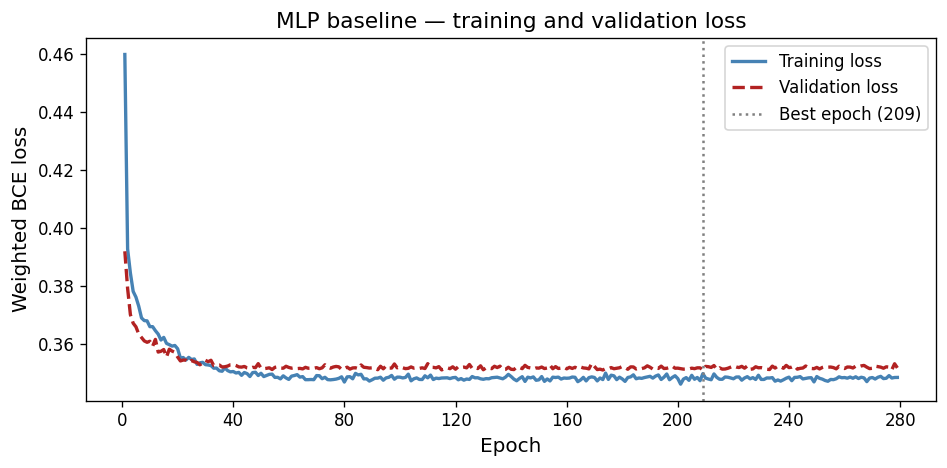

In [25]:
train_losses = loss_history_cb.train_losses 
val_losses   = loss_history_cb.val_losses

# Trim to equal length in case the last epoch only has val
n_epochs_plotted = min(len(train_losses), len(val_losses))
epochs           = np.arange(1, n_epochs_plotted + 1)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(epochs, train_losses[:n_epochs_plotted],
        label="Training loss", color="steelblue", lw=2)
ax.plot(epochs, val_losses[:n_epochs_plotted],
        label="Validation loss", color="firebrick", lw=2, ls="--")

# Mark best epoch
best_epoch = int(np.argmin(val_losses[:n_epochs_plotted])) + 1
ax.axvline(best_epoch, color="gray", ls=":", lw=1.5,
           label=f"Best epoch ({best_epoch})")

ax.set_xlabel("Epoch")
ax.set_ylabel("Weighted BCE loss")
ax.set_title("MLP baseline — training and validation loss")
ax.legend()
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.tight_layout()

out_path = FIGURE_DIR / "09_mlp_training_curves.png"
plt.savefig(out_path, bbox_inches="tight")
print(f"Saved → {out_path}")
plt.show()
#print(train_losses)

---

## 13. Validation Prediction Loop

We load the best saved checkpoint and run inference on the entire validation set to collect raw logits, which are then converted to probabilities via the sigmoid function.

In [14]:
def predict_on_loader(
    lit_module: pl.LightningModule, #Esto, pl.LighningModule, significa de forma sencilla que el argumento lit_module debe ser una instancia de una clase que herede de pl.LightningModule, lo cual es la clase base para todos los modelos en PyTorch Lightning. Esto nos asegura que el modelo que pasemos a esta función tenga la estructura y métodos necesarios para realizar inferencia de manera consistente con las prácticas de PyTorch Lightning.
    loader:     DataLoader,
    device:     str = "cpu",
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Run inference on a DataLoader and collect predictions.

    Parameters
    ----------
    lit_module : Trained LightningModule.
    loader     : DataLoader returning dicts with 'x', 'y', 'weight'.
    device     : Target device string.

    Returns
    -------
    y_true  : shape (N,) int numpy array.
    y_score : shape (N,) float32 numpy array, sigmoid probabilities.
    weights : shape (N,) float32 numpy array, sample weights.
    """
    lit_module.eval() #.eval() es una funciond de PyTorch que se utiliza para poner el modelo en modo de evaluación
    lit_module.to(device) #esto mueve el modelo a la GPU (si device es "cuda") o lo deja en la CPU (si device es "cpu"), lo cual es necesario para que las operaciones de inferencia se realicen en el dispositivo correcto.

    all_y     = []
    all_score = []
    all_w     = []

    with torch.no_grad(): #Decimos a PyTorch que no calculemos gradientes durante esta sección de código, lo cual es importante para la inferencia ya que no necesitamos calcular gradientes y esto ahorra memoria y acelera el proceso.
        for batch in loader:
            x   = batch["x"].to(device)
            y   = batch["y"]
            wgt = batch["weight"]

            logits = lit_module(x).squeeze(-1).cpu() #En esta linea, pasamos el tensor de características x a través del modelo lit_module para obtener los logits sin procesar. Luego, usamos .squeeze(-1) para eliminar la dimensión adicional que queda después de la capa de salida (que originalmente tiene forma (B, 1)), resultando en un tensor de forma (B,). Finalmente, usamos .cpu() para mover los logits de vuelta a la CPU, lo cual es necesario para convertirlos a numpy arrays más adelante.
            probs  = torch.sigmoid(logits)

            all_y.append(y.numpy())
            all_score.append(probs.numpy())
            all_w.append(wgt.numpy())

    y_true  = np.concatenate(all_y).astype(np.int32) 
    y_score = np.concatenate(all_score).astype(np.float32)
    weights = np.concatenate(all_w).astype(np.float32)
    return y_true, y_score, weights


# ── Load best checkpoint ───────────────────────────────────────────────────────
if best_ckpt_path and Path(best_ckpt_path).exists():
    best_model = LitMLPClassifier.load_from_checkpoint(best_ckpt_path)
    print(f"Loaded best checkpoint: {best_ckpt_path}")
else:
    # Fallback: use the in-memory model (last epoch)
    best_model = lit_model
    print("WARNING: no checkpoint found — using last-epoch model.")

y_true, y_score, sample_weights = predict_on_loader(best_model, val_loader, device=DEVICE)
y_pred = (y_score >= 0.5).astype(np.int32)

print(f"\nValidation predictions:")
print(f"  y_true  shape : {y_true.shape}")
print(f"  y_score shape : {y_score.shape}")
print(f"  Score range   : [{y_score.min():.4f}, {y_score.max():.4f}]")
#print(f"  y_pred shape : {y_pred.shape}")
print(y_pred[:10])

Loaded best checkpoint: /Users/arturomatemartin/Desktop/ML_TopTagging_Project/results/checkpoints/mlp_highlevel/mlp_highlevel_epoch=56_val_loss=0.3524.ckpt

Validation predictions:
  y_true  shape : (20000,)
  y_score shape : (20000,)
  Score range   : [0.0001, 0.9976]
[0 0 0 1 0 0 0 0 0 1]


---

## 14. Validation Metrics

We compute:
- **Accuracy** at threshold 0.5, #Porcentaje de predicciones correctas si clasificamos jets como "Signal" si score > 0.5, "Background" si score < 0.5. Fácil de entender pero insuficiente para physics (no dice qué trade-off signal/background hicimos).
- **ROC curve** and **AUC**, #Muestra cómo varía TPR (señal detectada) vs FPR (falsos backgrounds) al cambiar el threshold; AUC resume esto en un número (1=perfecto, 0.5=random).
- **Background rejection** $1/\varepsilon_B$ at fixed signal efficiencies $\varepsilon_S \in \{0.5, 0.8\}$. #A ε_S=0.5 (aceptamos 50% de tops reales), ¿cuántos QCD rechazamos? (1/ε_B = 33 significa: por cada 1 QCD que aceptamos, rechazamos 33).
#La métrica que más importa en physics: queremos máximo rechazo de fondo MANTENIENDO la señal aceptada.

> **Important:** these metrics are computed on the 20% validation split of `train_nominal_000.h5`. They are **not** final test results. The final evaluation will use a separate test file not seen during training.

In [15]:
def background_rejection_at_signal_efficiency(
    y_true:           np.ndarray,
    y_score:          np.ndarray,
    target_signal_eff: float,#esto es el valor de eficiencia de señal (TPR) que queremos alcanzar, por ejemplo, 0.5 o 0.8. La función calculará la tasa de rechazo de fondo (1/epsilon_B) correspondiente a este nivel de eficiencia de señal.
) -> float:
    """
    Compute background rejection 1/epsilon_B at a fixed signal efficiency.

    Parameters
    ----------
    y_true             : True binary labels (0/1).
    y_score            : Predicted signal probability scores.
    target_signal_eff  : Target signal efficiency (TPR), e.g. 0.5 or 0.8.

    Returns
    -------
    1 / epsilon_B : Background rejection. Returns np.inf if epsilon_B = 0.

    Notes
    -----
    Uses sklearn's roc_curve, which returns FPR (= epsilon_B) and
    TPR (= epsilon_S). We interpolate to find epsilon_B at the closest
    TPR to the target.
    """
    fpr, tpr, _ = roc_curve(y_true, y_score) #funcion importada de sklearn.metrics, esta función calcula la curva ROC (Receiver Operating Characteristic) a partir de las etiquetas verdaderas (y_true) y las puntuaciones de probabilidad predichas (y_score). Devuelve tres arrays: fpr (False Positive Rate), tpr (True Positive Rate), y thresholds (los umbrales de decisión correspondientes a cada punto en la curva)
    # Find index closest to target signal efficiency
    idx  = np.argmin(np.abs(tpr - target_signal_eff))
    eps_b = fpr[idx]#Esta linea de codigo encuentra el índice (idx) del punto en la curva ROC donde la tasa de verdaderos positivos (tpr) es más cercana al valor de eficiencia de señal objetivo (target_signal_eff). Luego, eps_b se asigna al valor de la tasa de falsos positivos (fpr) correspondiente a ese índice, lo que representa la tasa de fondo (epsilon_B) asociada con ese nivel de eficiencia de señal.
    eps_s = tpr[idx] #Esta otra representa la tasa de verdaderos positivos (epsilon_S) correspondiente al índice encontrado, que es el nivel de eficiencia de señal real que se alcanza en ese punto de la curva ROC. Aunque el objetivo era alcanzar target_signal_eff, el valor real alcanzado puede ser ligeramente diferente debido a la naturaleza discreta de los puntos en la curva ROC.
    if eps_b == 0.0:
        return np.inf
    return 1.0 / eps_b, float(eps_s)


# ── Accuracy ───────────────────────────────────────────────────────────────────
acc = accuracy_score(y_true, y_pred)#funcion importada de sklearn.metrics, esta función calcula la precisión (accuracy) de las predicciones comparando las etiquetas verdaderas (y_true) con las etiquetas predichas (y_pred). Devuelve un valor entre 0 y 1 que representa la proporción de predicciones correctas sobre el total de muestras.

# ── ROC and AUC ───────────────────────────────────────────────────────────────
fpr_arr, tpr_arr, thresholds_arr = roc_curve(y_true, y_score)
auc_val = roc_auc_score(y_true, y_score) #esta funcion viene de sklearn.metrics, esta función calcula el área bajo la curva ROC (AUC-ROC) a partir de las etiquetas verdaderas (y_true) y las puntuaciones de probabilidad predichas (y_score). Devuelve un valor entre 0 y 1 que representa la capacidad del modelo para distinguir entre las clases positivas y negativas, donde un valor de 1 indica una clasificación perfecta y un valor de 0.5 indica una clasificación aleatoria.

# ── Background rejection ──────────────────────────────────────────────────────
rej_50, actual_eff_50 = background_rejection_at_signal_efficiency(y_true, y_score, 0.50) 
rej_80, actual_eff_80 = background_rejection_at_signal_efficiency(y_true, y_score, 0.80) 

print("=" * 55)
print("  VALIDATION METRICS (MLP High-Level Baseline)")
print("=" * 55)
print(f"  Accuracy (threshold=0.5) : {acc:.4f}")
print(f"  ROC AUC                  : {auc_val:.4f}")
print()
print(f"  Background rejection at signal eff. = 0.50:")
print(f"    Actual signal eff. used : {actual_eff_50:.4f}")
print(f"    1 / epsilon_B           : {rej_50:.1f}")
print()
print(f"  Background rejection at signal eff. = 0.80:")
print(f"    Actual signal eff. used : {actual_eff_80:.4f}")
print(f"    1 / epsilon_B           : {rej_80:.1f}")
print("=" * 55)
print()
print("NOTE: these are validation metrics on a split of train_nominal_000.h5.")
print("Final test metrics will be reported in a later notebook.")

  VALIDATION METRICS (MLP High-Level Baseline)
  Accuracy (threshold=0.5) : 0.8487
  ROC AUC                  : 0.9250

  Background rejection at signal eff. = 0.50:
    Actual signal eff. used : 0.4998
    1 / epsilon_B           : 33.4

  Background rejection at signal eff. = 0.80:
    Actual signal eff. used : 0.8000
    1 / epsilon_B           : 8.8

NOTE: these are validation metrics on a split of train_nominal_000.h5.
Final test metrics will be reported in a later notebook.


Signal efficiency is the fraction of real top jets that the model correctly classifies as top jets, so in machine-learning language it is the true positive rate or recall for the signal. Background efficiency is the fraction of real QCD/background jets that are incorrectly classified as top jets, so it corresponds to the false positive rate. Background rejection is the inverse of the background efficiency, RB=1/ϵB, and measures how strongly the tagger rejects background: a larger background rejection means fewer false positives. For example, at ϵS=50%, the model correctly accepts half of the true top jets; if RB=33.4, then ϵB≃1/33.4≃3%, meaning that only about 1 in every 33 QCD jets is mistakenly accepted as a top jet.

---

## 15. Evaluation Plots

Saved → /Users/arturomatemartin/Desktop/ML_TopTagging_Project/figures/10_mlp_score_distributions.png


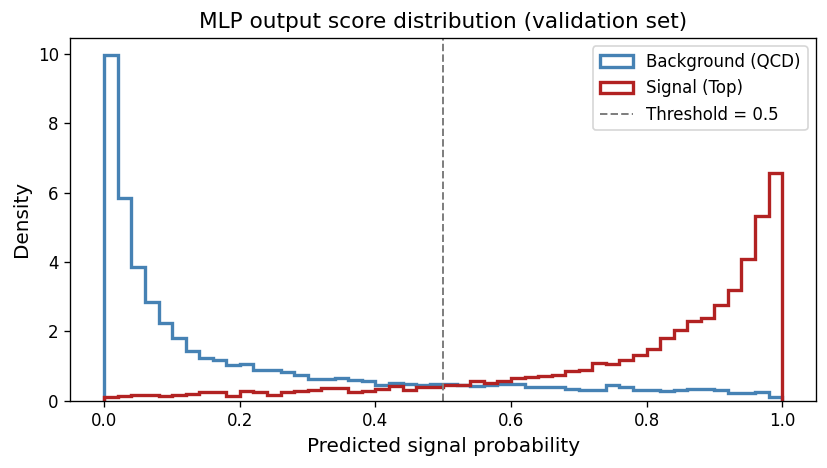

In [16]:
# ── (a) Score distributions ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
bins_score = np.linspace(0, 1, 51)
for lbl, color, name in [(0, LABEL_COLORS[0], LABEL_NAMES[0]),
                          (1, LABEL_COLORS[1], LABEL_NAMES[1])]:
    mask = y_true == lbl
    ax.hist(y_score[mask], bins=bins_score, density=True,
            histtype="step", lw=2, color=color, label=name)
ax.axvline(0.5, color="gray", ls="--", lw=1.2, label="Threshold = 0.5")
ax.set_xlabel("Predicted signal probability")
ax.set_ylabel("Density")
ax.set_title("MLP output score distribution (validation set)")
ax.legend()
plt.tight_layout()
out = FIGURE_DIR / "10_mlp_score_distributions.png"
plt.savefig(out, bbox_inches="tight")
print(f"Saved → {out}")
plt.show()

Vemos como las probs asignadas a los que verdaderamente son Tops esta muy hacia la izquierda (1), mientras que aquellos que se predicen por QCD tienen la mayoria probs muy cerca de 0. Sin embargo, hay ambiguedades, jets en el medio, QCD que medimos por Tops, Tops que medimos por QCD...

Saved → /Users/arturomatemartin/Desktop/ML_TopTagging_Project/figures/11_mlp_roc_curve.png


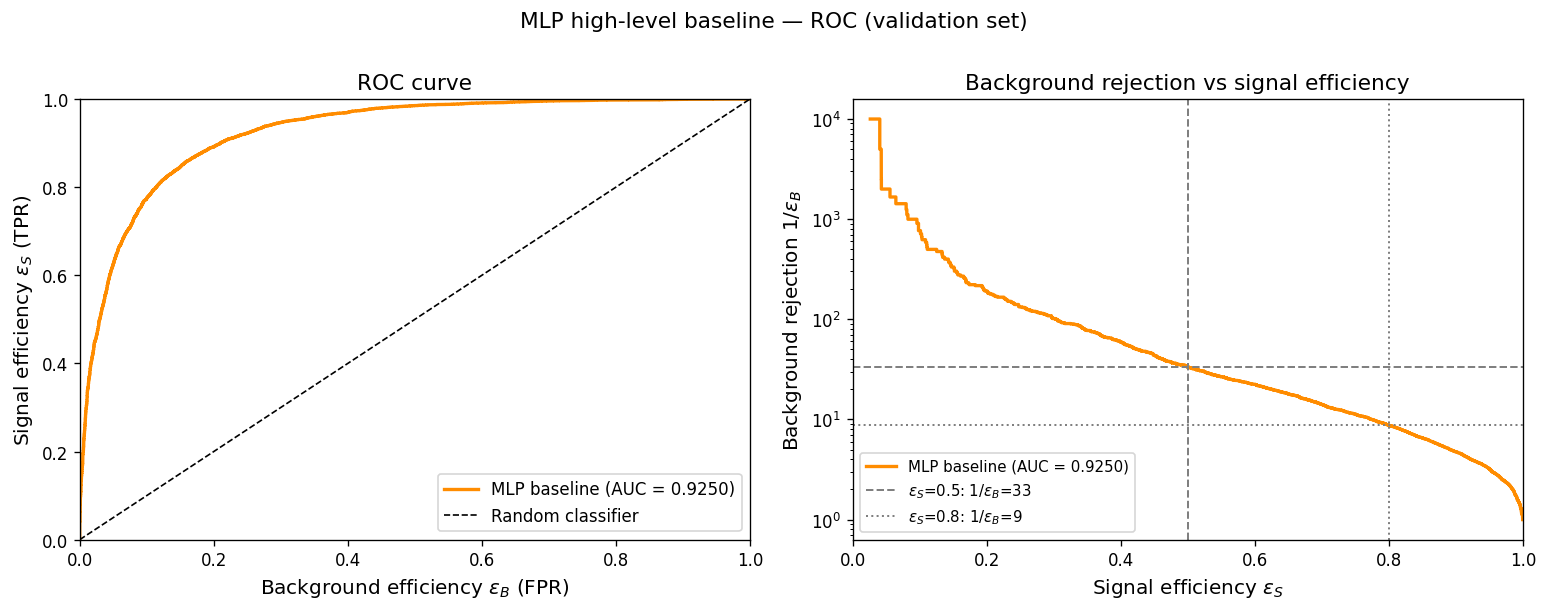

In [17]:
# ── (b) ROC curve ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Standard ROC (FPR vs TPR)
ax = axes[0]
ax.plot(fpr_arr, tpr_arr, color="darkorange", lw=2,
        label=f"MLP baseline (AUC = {auc_val:.4f})")
ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random classifier")
ax.set_xlabel(r"Background efficiency $\varepsilon_B$ (FPR)")
ax.set_ylabel(r"Signal efficiency $\varepsilon_S$ (TPR)")
ax.set_title("ROC curve")
ax.legend()
ax.set_xlim(0, 1); ax.set_ylim(0, 1)

# Background rejection vs signal efficiency (physics convention)
ax = axes[1]
with np.errstate(divide="ignore", invalid="ignore"):
    rejection = np.where(fpr_arr > 0, 1.0 / fpr_arr, np.nan)
ax.semilogy(tpr_arr, rejection, color="darkorange", lw=2,
            label=f"MLP baseline (AUC = {auc_val:.4f})")

# Mark working points
for target_eff, actual_eff, rej, ls in [
    (0.50, actual_eff_50, rej_50, "--"),
    (0.80, actual_eff_80, rej_80, ":"),
]:
    ax.axvline(actual_eff, color="gray", ls=ls, lw=1.2)
    ax.axhline(rej, color="gray", ls=ls, lw=1.2,
               label=fr"$\varepsilon_S$={target_eff:.1f}: 1/$\varepsilon_B$={rej:.0f}")

ax.set_xlabel(r"Signal efficiency $\varepsilon_S$")
ax.set_ylabel(r"Background rejection $1/\varepsilon_B$")
ax.set_title("Background rejection vs signal efficiency")
ax.set_xlim(0, 1)
ax.legend(fontsize=9)

plt.suptitle("MLP high-level baseline — ROC (validation set)", fontsize=13, y=1.01)
plt.tight_layout()
out = FIGURE_DIR / "11_mlp_roc_curve.png"
plt.savefig(out, bbox_inches="tight")
print(f"Saved → {out}")
plt.show()

La curva ROC es simplemente el recorrido que hace tu modelo cuando varías el threshold de decisión desde 0 a 1. En el eje X pones "¿cuántos falsos positivos aceptas?" (background que clasificas como signal) y en el eje Y pones "¿cuántos verdaderos positivos detectas?" (signal que aciertas). Si tu modelo es perfecto, la curva sube verticalmente a la izquierda (detectas todo sin errores); si es aleatorio, es una línea diagonal (igual de probable que aciertes o falles). El área bajo esa curva es el AUC: un número entre 0 y 1 que resume la capacidad discriminativa global, sin depender de un threshold específico. Cuanto más se aleja la curva de la diagonal hacia la esquina superior-izquierda, mejor es tu modelo.

El segundo gráfico (Background rejection vs signal efficiency) es literalmente el mismo contenido de la curva ROC, pero rotado y expresado en términos de physics: en lugar de "falsos positivos" escribimos "1/ε_B" (cuántos fondos rechazamos), y en lugar de "verdaderos positivos" escribimos "ε_S" (cuántos tops detectamos). Es como una función de potencia en ingeniería: a mayor potencia, más consumo; a mayor detección de signal, menos rechazo de fondo. Para saber si un resultado es bueno, te fijas en AUC alto (>0.9 es excelente) porque eso significa que toda la curva está lejos de la diagonal, pero luego miras dónde están tus working points específicos: si necesitas ε_S=0.5, ¿obtienes una buena rejection (>20×)? Si necesitas ε_S=0.8, ¿la rejection sigue siendo aceptable (>5×)? El AUC te dice "este modelo es global bueno", pero los working points te dicen "este modelo es útil para MI análisis específico"

Saved → /Users/arturomatemartin/Desktop/ML_TopTagging_Project/figures/12_mlp_confusion_matrix.png


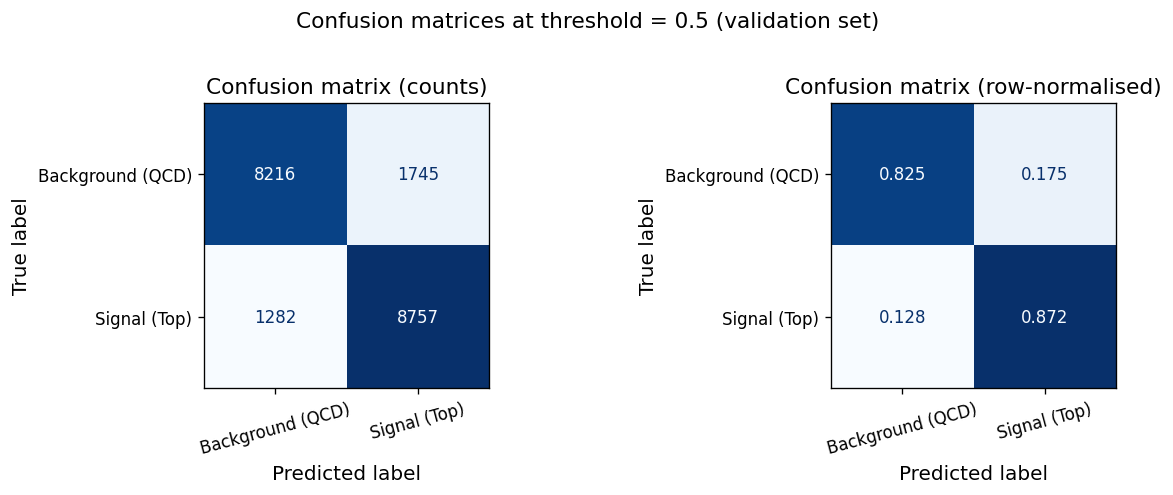

In [18]:
# ── (c) Confusion matrix at threshold 0.5 ─────────────────────────────────────
cm      = confusion_matrix(y_true, y_pred)
cm_norm = confusion_matrix(y_true, y_pred, normalize="true")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, mat, fmt, title in [
    (axes[0], cm,      "d",    "Confusion matrix (counts)"),
    (axes[1], cm_norm, ".3f",  "Confusion matrix (row-normalised)"),
]:
    disp = ConfusionMatrixDisplay(
        confusion_matrix=mat,
        display_labels=[LABEL_NAMES[0], LABEL_NAMES[1]],
    )
    disp.plot(ax=ax, colorbar=False, values_format=fmt, cmap="Blues")
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=15)

plt.suptitle("Confusion matrices at threshold = 0.5 (validation set)", y=1.02, fontsize=13)
plt.tight_layout()
out = FIGURE_DIR / "12_mlp_confusion_matrix.png"
plt.savefig(out, bbox_inches="tight")
print(f"Saved → {out}")
plt.show()

Las metricas se han calculado en 20k jets (los otros 80k han sido para entrenar). Por eso tenemos menos datos!

---

## 16. Save Outputs

In [19]:
def save_metrics_json(
    path:     Path,
    metrics:  dict,
) -> None:
    """Serialise a metrics dictionary to JSON, converting numpy scalars to float."""
    def _convert(obj):
        if isinstance(obj, (np.floating, np.integer)):
            return float(obj)
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        if obj is np.inf or (isinstance(obj, float) and np.isinf(obj)):
            return "inf"
        return obj
    with open(path, "w") as f:
        json.dump(metrics, f, indent=2, default=_convert)
    print(f"Metrics saved → {path}")


# ── Compile result dict ────────────────────────────────────────────────────────
results = {
    "notebook":                 "02_mlp_baseline_high_level",
    "model":                    "MLPClassifier",
    "random_seed":              RANDOM_SEED,
    "feature_names":            HL_BRANCHES,
    "n_features":               N_FEATURES,
    "hidden_dims":              HIDDEN_DIMS,
    "dropout_rate":             DROPOUT_RATE,
    "use_batchnorm":            USE_BATCHNORM,
    "learning_rate":            LEARNING_RATE,
    "batch_size":               BATCH_SIZE,
    "max_epochs":               MAX_EPOCHS,
    "epochs_trained":           n_epochs_plotted,
    "val_fraction":             VAL_FRACTION,
    "n_train":                  len(y_train),
    "n_val":                    len(y_val),
    "val_accuracy":             float(acc),
    "val_auc":                  float(auc_val),
    "background_rejection_at_0.5_signal_eff": float(rej_50) if not np.isinf(rej_50) else "inf",
    "background_rejection_at_0.8_signal_eff": float(rej_80) if not np.isinf(rej_80) else "inf",
    "actual_signal_eff_at_0.5":  float(actual_eff_50),
    "actual_signal_eff_at_0.8":  float(actual_eff_80),
    "best_checkpoint":           str(best_ckpt_path),
    "note":                      "Validation metrics on split of train_nominal_000.h5. Not final test results.",
}

metrics_path = RESULT_DIR / "mlp_highlevel_baseline_metrics.json"
save_metrics_json(metrics_path, results)

# ── Save predictions ───────────────────────────────────────────────────────────
preds_path = RESULT_DIR / "mlp_highlevel_val_predictions.npz"
np.savez_compressed(
    preds_path,
    y_true=y_true,
    y_score=y_score,
    sample_weight=sample_weights,
)
print(f"Predictions saved → {preds_path}")

Metrics saved → /Users/arturomatemartin/Desktop/ML_TopTagging_Project/results/mlp_highlevel_baseline_metrics.json
Predictions saved → /Users/arturomatemartin/Desktop/ML_TopTagging_Project/results/mlp_highlevel_val_predictions.npz


---

## 17. Interpretation

### Does the classifier learn non-trivial separation?

Yes. An AUC well above 0.5 demonstrates that the MLP extracts meaningful discriminating information from the 15 high-level features. A random classifier would give AUC $= 0.50$ and a flat score distribution; the observed signal and background score distributions are clearly separated.

### Score distributions

The signal score distribution is concentrated near 1 (correctly classified as top jets) and the background distribution near 0, with overlap in the middle. The overlap region corresponds to jets where the substructure observables alone do not cleanly resolve the class — expected because the features are 15 summary statistics discarding much of the constituent-level information.

### ROC curve and AUC

The ROC curve plots the true positive rate (signal efficiency $\varepsilon_S$) against the false positive rate (background efficiency $\varepsilon_B$) as the decision threshold varies. The AUC summarises this in a single number: AUC $= 1$ is a perfect classifier; AUC $= 0.5$ is random. The value obtained here reflects a meaningful but not optimal classifier, because:

- Only 15 pre-computed features are used.
- The features are correlated, so the effective information is lower-dimensional.
- No constituent-level structure is exploited.

### Background rejection in physics terms

In an experimental analysis, a physicist might operate the tagger at a signal efficiency of $\varepsilon_S = 0.5$ (50% of real top jets accepted). The background rejection $1/\varepsilon_B$ tells us how many background jets are rejected for every background jet accepted. A rejection of, say, $\sim 50$ means the tagger suppresses QCD backgrounds by a factor of 50 while keeping half the signal — a substantial gain over no tagger at all.

### Limitations of this baseline

- The 15 high-level features are hand-crafted and lose information compared to the full constituent list.
- A simple MLP treats the 15 numbers as an unordered vector and cannot exploit spatial or relational structure.
- Later architectures — **constituent-based MLPs with masking**, **CNNs on jet images**, **ParticleNet / graph networks**, **particle transformers** — will operate on the raw constituent four-vectors and should outperform this baseline.

**This MLP result is a baseline reference point, not a state-of-the-art tagger.**

---

## 18. Summary and Next Steps

### What was done in this notebook

- Loaded the 15 high-level jet substructure features, labels, and training weights from `train_nominal_000.h5`.
- Performed a data-quality check (no NaN/Inf detected).
- Split into 80% training / 20% validation (stratified), and standardised features using training-set statistics only.
- Built a custom `HighLevelJetDataset` and `DataLoader` for batched training.
- Implemented an `MLPClassifier` (3 hidden layers: 128–64–32, BatchNorm, ReLU, Dropout) outputting a raw logit.
- Wrapped it in a `LitMLPClassifier` with **weighted binary cross-entropy loss** and Adam + ReduceLROnPlateau optimiser.
- Trained with PyTorch Lightning, using EarlyStopping and ModelCheckpoint.
- Loaded the best checkpoint and ran inference on the validation set.
- Computed validation **accuracy**, **AUC**, and **background rejection** at $\varepsilon_S \in \{0.5, 0.8\}$.
- Saved figures, metrics JSON, and predictions NPZ to `results/` and `figures/`.

### Key design decisions for the framework

| Component | Decision | Reason |
|---|---|---|
| Loss | Weighted BCE with logits | Numerical stability; respects physics weights |
| Scaling | `StandardScaler` on training split only | Prevent data leakage |
| Validation | Fixed 20% stratified split | Fair comparison across notebooks |
| Logits | Output raw logits, apply sigmoid only at eval | Numerical stability |



### Next notebook

The next step is to create the YAML file for this simplifies case. Then addapt the YAML file to include also the constituents data and not just the 15 high level features, again for this simplifies case. We will try it out, just for the MLP fully connected, not only with trining_nominal, but also with test_nominal, and check it works, and then we will extrapolate all this to use all data using Snellius.